In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("/Users/armandovieira/Tartu/loan_sample.csv")

/var/folders/t0/9v5z856d2k98pczzxd6yw3qh0000gn/T/ipykernel_95569/745164091.py:1: DtypeWarning: Columns (123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/Users/armandovieira/Tartu/loan_sample.csv")


In [4]:
data.dtypes

id                       float64
member_id                float64
loan_amnt                  int64
funded_amnt                int64
funded_amnt_inv            int64
                          ...   
settlement_status         object
settlement_date           object
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
Length: 145, dtype: object

<Axes: >

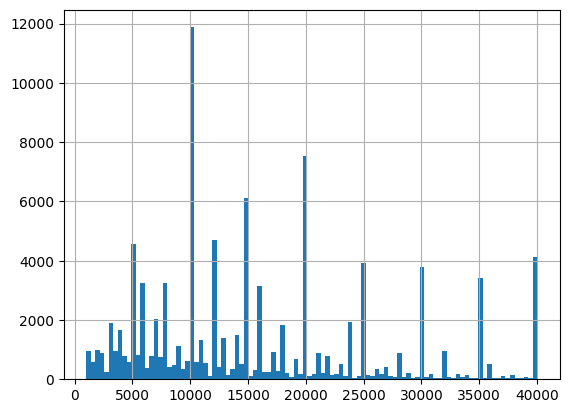

In [9]:
data["loan_amnt"].hist(bins=100)

In [ ]:
data["loan_status"].value_counts() 
/Users/armandovieira/Projects/Vamstar/gita/stream_output/24-04-2026_01/05_normalized_data/BOLZANO_normalized_lot_participant_level.json

loan_status
Current               96792
Fully Paid             2431
Late (31-120 days)      318
In Grace Period         316
Late (16-30 days)       123
Charged Off              19
Name: count, dtype: int64

In [15]:
for d in data.columns:
    try:
        print(d, data[d].dtype, data[d].min(), data[d].max()) #  data[d].isnull().sum())
    except:
        continue

id float64 nan nan
member_id float64 nan nan
loan_amnt int64 1000 40000
funded_amnt int64 1000 40000
funded_amnt_inv int64 725 40000
term object  36 months  60 months
int_rate float64 6.0 30.99
installment float64 30.64 1618.24
grade object A G
sub_grade object A1 G5
home_ownership object ANY RENT
annual_inc float64 0.0 9757200.0
verification_status object Not Verified Verified
issue_d object Dec-2018 Oct-2018
loan_status object Charged Off Late (31-120 days)
pymnt_plan object n y
url float64 nan nan
desc float64 nan nan
purpose object car vacation
title object Business Vacation
zip_code object 010xx 999xx
addr_state object AK WY
dti float64 0.0 999.0
delinq_2yrs int64 0 24
earliest_cr_line object Apr-1962 Sep-2015
inq_last_6mths int64 0 5
mths_since_last_delinq float64 0.0 160.0
mths_since_last_record float64 5.0 119.0
open_acc int64 0 68
pub_rec int64 0 6
revol_bal int64 0 2358150
revol_util float64 0.0 183.8
total_acc int64 2 133
initial_list_status object f w
out_prncp float64 0.0 

In [16]:
import requests
import pandas as pd

def download_grand_network(cancer_type="BRCA", network_type="PANDA", save_path="grn_network.csv"):
    """
    Download a pre-computed GRN from GRAND database.
    
    cancer_type options: BRCA, LUAD, COAD, GBM, KIRC, OV, UCEC, etc.
    network_type: PANDA (TF-gene), LIONESS (sample-specific)
    """
    # GRAND API base URL
    base_url = "https://grand.networkmedicine.org/api/v1/"
    
    # List available networks first
    response = requests.get(f"{base_url}networks/", params={"cancer": cancer_type})
    
    if response.status_code == 200:
        networks = response.json()
        print(f"Available networks for {cancer_type}:")
        for net in networks[:5]:
            print(f"  {net}")
    else:
        print(f"Status: {response.status_code} — trying direct download...")

    # Direct download URL pattern for GRAND cancer networks
    download_url = f"https://grand.networkmedicine.org/cancer/{cancer_type.lower()}/"
    print(f"Try manual download at: {download_url}")
    
    return download_url

download_grand_network("BRCA")

Status: 404 — trying direct download...
Try manual download at: https://grand.networkmedicine.org/cancer/brca/


'https://grand.networkmedicine.org/cancer/brca/'

In [17]:
"""
Publication-quality visualizations for RAF/GRN cancer-network analysis.

Expected inputs from your existing analysis:
    G              : networkx.DiGraph with optional edge attribute 'weight'
    raf_set        : set[str] of genes in the maxRAF core
    food_set       : set[str] of food-set / external-input genes
    keystone_df    : pandas.DataFrame with columns such as:
                    ['gene', 'K', 'K_frac', 'kappa', 'out_degree', 'in_degree', 'D']
    bridge_df      : pandas.DataFrame with columns such as:
                    ['source', 'target', 'B', 'weight']
    gatekeeper_df  : pandas.DataFrame with columns such as:
                    ['gene', 'gamma', 'Gamma', 'KF', 'out_degree']

The functions are intentionally defensive: they normalize common column-name variants
from LaTeX/table exports, create missing directories, and save high-resolution figures.
"""

from __future__ import annotations

from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# Global style
# -----------------------------------------------------------------------------


def set_publication_style() -> None:
    """Use a clean, journal-friendly Matplotlib style."""
    plt.rcParams.update(
        {
            "figure.dpi": 140,
            "savefig.dpi": 300,
            "font.size": 10,
            "axes.titlesize": 13,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.22,
            "grid.linewidth": 0.6,
            "figure.autolayout": True,
        }
    )


def ensure_dir(path: str | Path) -> Path:
    out = Path(path)
    out.mkdir(parents=True, exist_ok=True)
    return out


def save_figure(fig: plt.Figure, output_dir: str | Path, filename: str) -> Path:
    output_dir = ensure_dir(output_dir)
    path = output_dir / filename
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return path


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize common column variants from paper tables or scripts."""
    rename_map = {
        "Gene": "gene",
        "K(v)": "K",
        "Khat": "K_frac",
        "K_hat": "K_frac",
        "K̂(v) (%)": "K_frac_percent",
        "K_frac_percent": "K_frac_percent",
        "κ(v)": "kappa",
        "kappa(v)": "kappa",
        "k+": "out_degree",
        "k_minus": "in_degree",
        "k-": "in_degree",
        "D(v)": "D",
        "Source": "source",
        "Target": "target",
        "B(u,v)": "B",
        "γ(f)": "gamma",
        "Gamma(f)": "Gamma",
        "Γ(f)": "Gamma",
        "KF(f)": "KF",
    }

    out = df.copy()
    out.columns = [rename_map.get(c, c) for c in out.columns]

    if "K_frac" not in out.columns and "K_frac_percent" in out.columns:
        out["K_frac"] = out["K_frac_percent"] / 100.0

    return out


# -----------------------------------------------------------------------------
# 1. Keystone bar chart
# -----------------------------------------------------------------------------


def plot_keystone_bar(
    keystone_df: pd.DataFrame,
    output_dir: str | Path = "figures",
    top_n: int = 20,
    filename: str = "fig1_top_raf_keystones.png",
) -> Path:
    """Horizontal bar chart of top RAF keystones by collapse K(v)."""
    set_publication_style()
    df = normalize_columns(keystone_df)

    required = {"gene", "K"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"keystone_df is missing required columns: {missing}")

    df = df.sort_values("K", ascending=False).head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7.2, 0.36 * len(df) + 1.8))
    bars = ax.barh(df["gene"], df["K"], edgecolor="black", linewidth=0.4)

    ax.set_title("Top RAF Keystone Genes by Collapse Impact")
    ax.set_xlabel(r"RAF collapse after removal, $K(v)$")
    ax.set_ylabel("")

    for bar, value in zip(bars, df["K"]):
        ax.text(
            value + max(df["K"].max() * 0.02, 0.05),
            bar.get_y() + bar.get_height() / 2,
            f"{value:g}",
            va="center",
            ha="left",
        )

    return save_figure(fig, output_dir, filename)


# -----------------------------------------------------------------------------
# 2. Catalyticity vs disruption scatter
# -----------------------------------------------------------------------------


def plot_disruption_scatter(
    keystone_df: pd.DataFrame,
    output_dir: str | Path = "figures",
    filename: str = "fig2_keystone_vs_catalyticity.png",
    label_top_n: int = 8,
) -> Path:
    """
    Scatter plot showing why RAF keystones are not identical to hubs.

    x-axis: catalyticity κ(v)
    y-axis: RAF collapse K(v)
    point size: composite disruption score D(v), if available
    """
    set_publication_style()
    df = normalize_columns(keystone_df)

    required = {"gene", "K", "kappa"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"keystone_df is missing required columns: {missing}")

    if "D" in df.columns:
        sizes = 80 + 420 * (df["D"] - df["D"].min()) / (df["D"].max() - df["D"].min() + 1e-9)
    else:
        sizes = np.full(len(df), 180)

    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    ax.scatter(
        df["kappa"],
        df["K"],
        s=sizes,
        alpha=0.78,
        edgecolor="black",
        linewidth=0.55,
    )

    label_df = df.sort_values(["K", "kappa"], ascending=False).head(label_top_n)
    for _, row in label_df.iterrows():
        ax.annotate(
            row["gene"],
            xy=(row["kappa"], row["K"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    ax.set_title("RAF Keystone Impact Is Not Equivalent to Catalyticity")
    ax.set_xlabel(r"Catalyticity score, $\kappa(v)$")
    ax.set_ylabel(r"RAF collapse, $K(v)$")

    if "D" in df.columns:
        ax.text(
            0.99,
            0.02,
            "Point size ∝ composite disruption score",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
        )

    return save_figure(fig, output_dir, filename)


# -----------------------------------------------------------------------------
# 3. RAF core network visualization
# -----------------------------------------------------------------------------


def _select_network_nodes(
    G: nx.DiGraph,
    raf_set: set[str],
    food_set: set[str],
    keystone_df: Optional[pd.DataFrame],
    bridge_df: Optional[pd.DataFrame],
    max_nodes: int,
) -> set[str]:
    """Select a readable subgraph around important RAF nodes."""
    selected: set[str] = set()

    if keystone_df is not None and not keystone_df.empty:
        kdf = normalize_columns(keystone_df)
        if {"gene", "K"}.issubset(kdf.columns):
            selected.update(kdf.sort_values("K", ascending=False).head(max_nodes // 3)["gene"].astype(str))

    if bridge_df is not None and not bridge_df.empty:
        bdf = normalize_columns(bridge_df)
        if {"source", "target", "B"}.issubset(bdf.columns):
            top_edges = bdf.sort_values("B", ascending=False).head(max_nodes // 3)
            selected.update(top_edges["source"].astype(str))
            selected.update(top_edges["target"].astype(str))

    # Add neighbours to give context.
    expanded = set(selected)
    for node in selected:
        if node in G:
            expanded.update(list(G.predecessors(node))[:5])
            expanded.update(list(G.successors(node))[:5])

    # Prioritize RAF nodes and keep graph readable.
    ranked = sorted(
        expanded,
        key=lambda n: (
            n in raf_set,
            G.degree(n) if n in G else 0,
        ),
        reverse=True,
    )
    return set(ranked[:max_nodes])


def plot_raf_core_network(
    G: nx.DiGraph,
    raf_set: Iterable[str],
    food_set: Iterable[str],
    keystone_df: Optional[pd.DataFrame] = None,
    bridge_df: Optional[pd.DataFrame] = None,
    output_dir: str | Path = "figures",
    filename: str = "fig3_raf_core_network.png",
    max_nodes: int = 80,
    seed: int = 42,
) -> Path:
    """
    Draw a readable RAF-core subnetwork.

    Visual encoding:
        - larger nodes: higher keystone collapse K(v)
        - outlined nodes: selected RAF/core genes
        - square nodes: food-set inputs
        - thicker edges: higher edge weight
    """
    set_publication_style()

    raf_set = set(map(str, raf_set))
    food_set = set(map(str, food_set))

    selected_nodes = _select_network_nodes(G, raf_set, food_set, keystone_df, bridge_df, max_nodes)
    H = G.subgraph(selected_nodes).copy()

    if H.number_of_nodes() == 0:
        raise ValueError("Selected subgraph is empty. Check that gene names match G nodes.")

    k_scores = {}
    if keystone_df is not None and not keystone_df.empty:
        kdf = normalize_columns(keystone_df)
        if {"gene", "K"}.issubset(kdf.columns):
            k_scores = dict(zip(kdf["gene"].astype(str), kdf["K"].astype(float)))

    node_sizes = [130 + 120 * k_scores.get(n, 0) for n in H.nodes]
    edge_widths = [0.4 + 2.0 * float(H.edges[e].get("weight", 0.5)) for e in H.edges]

    pos = nx.spring_layout(H, seed=seed, k=0.55, weight="weight", iterations=100)

    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.set_title("RAF Core Subnetwork Around Keystone and Bridge Genes")
    ax.axis("off")

    raf_nodes = [n for n in H.nodes if n in raf_set and n not in food_set]
    food_nodes = [n for n in H.nodes if n in food_set]
    other_nodes = [n for n in H.nodes if n not in raf_set and n not in food_set]

    nx.draw_networkx_edges(
        H,
        pos,
        ax=ax,
        width=edge_widths,
        arrows=True,
        arrowsize=8,
        alpha=0.28,
        connectionstyle="arc3,rad=0.08",
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=other_nodes,
        node_size=[node_sizes[list(H.nodes).index(n)] for n in other_nodes],
        alpha=0.55,
        edgecolors="black",
        linewidths=0.4,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=raf_nodes,
        node_size=[node_sizes[list(H.nodes).index(n)] for n in raf_nodes],
        alpha=0.85,
        edgecolors="black",
        linewidths=0.7,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=food_nodes,
        node_shape="s",
        node_size=[node_sizes[list(H.nodes).index(n)] for n in food_nodes],
        alpha=0.85,
        edgecolors="black",
        linewidths=0.8,
        ax=ax,
    )

    # Label only the most important nodes to avoid clutter.
    label_candidates = set(sorted(k_scores, key=k_scores.get, reverse=True)[:12])
    label_candidates.update(food_nodes[:6])
    labels = {n: n for n in H.nodes if n in label_candidates}
    nx.draw_networkx_labels(H, pos, labels=labels, font_size=8, ax=ax)

    legend_text = "circle = RAF/core gene; square = food-set input; node size ∝ RAF collapse"
    ax.text(0.01, 0.01, legend_text, transform=ax.transAxes, fontsize=8, va="bottom")

    return save_figure(fig, output_dir, filename)


# -----------------------------------------------------------------------------
# 4. Bridge-edge criticality plot
# -----------------------------------------------------------------------------


def plot_bridge_edge_criticality(
    bridge_df: pd.DataFrame,
    output_dir: str | Path = "figures",
    top_n: int = 25,
    filename: str = "fig4_critical_bridge_edges.png",
) -> Path:
    """Plot the most critical bridge edges by RAF collapse B(u,v)."""
    set_publication_style()
    df = normalize_columns(bridge_df)

    required = {"source", "target", "B"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"bridge_df is missing required columns: {missing}")

    df = df.copy()
    df["edge"] = df["source"].astype(str) + r"$\rightarrow$" + df["target"].astype(str)
    df["is_self_loop"] = df["source"].astype(str) == df["target"].astype(str)
    df = df.sort_values("B", ascending=False).head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7.8, 0.34 * len(df) + 1.8))
    bars = ax.barh(df["edge"], df["B"], edgecolor="black", linewidth=0.4)

    for bar, is_self in zip(bars, df["is_self_loop"]):
        if is_self:
            bar.set_hatch("///")

    ax.set_title("Critical Bridge Edges in the RAF Core")
    ax.set_xlabel(r"RAF collapse after edge removal, $B(u,v)$")
    ax.set_ylabel("")
    ax.text(
        0.99,
        0.02,
        "hatched = autoregulatory self-loop",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
    )

    return save_figure(fig, output_dir, filename)


# -----------------------------------------------------------------------------
# 5. Food-set gatekeeper plot
# -----------------------------------------------------------------------------


def plot_gatekeeper_lollipop(
    gatekeeper_df: pd.DataFrame,
    output_dir: str | Path = "figures",
    top_n: int = 15,
    filename: str = "fig5_food_set_gatekeepers.png",
) -> Path:
    """
    Lollipop plot for food-set gatekeepers.

    x-axis: number of RAF members fed, γ(f)
    marker size: total feed strength, Γ(f)
    """
    set_publication_style()
    df = normalize_columns(gatekeeper_df)

    required = {"gene", "gamma"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"gatekeeper_df is missing required columns: {missing}")

    df = df.sort_values("gamma", ascending=False).head(top_n).iloc[::-1]

    if "Gamma" in df.columns:
        sizes = 70 + 350 * (df["Gamma"] - df["Gamma"].min()) / (df["Gamma"].max() - df["Gamma"].min() + 1e-9)
    else:
        sizes = np.full(len(df), 180)

    fig, ax = plt.subplots(figsize=(7.2, 0.38 * len(df) + 1.7))

    y = np.arange(len(df))
    ax.hlines(y=y, xmin=0, xmax=df["gamma"], linewidth=1.5, alpha=0.8)
    ax.scatter(df["gamma"], y, s=sizes, edgecolor="black", linewidth=0.55, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(df["gene"])
    ax.set_title("Food-Set Gatekeepers Feeding the RAF Core")
    ax.set_xlabel(r"RAF members directly fed, $\gamma(f)$")
    ax.set_ylabel("")

    if "Gamma" in df.columns:
        ax.text(
            0.99,
            0.02,
            r"Point size ∝ total feed strength, $\Gamma(f)$",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
        )

    return save_figure(fig, output_dir, filename)


# -----------------------------------------------------------------------------
# 6. Degree/catalyticity/disruption heatmap-style panel
# -----------------------------------------------------------------------------


def plot_target_metric_matrix(
    keystone_df: pd.DataFrame,
    output_dir: str | Path = "figures",
    top_n: int = 15,
    filename: str = "fig6_target_metric_matrix.png",
) -> Path:
    """
    Compact matrix comparing multiple metrics for top targets.

    This is useful for showing that ESR1/RUNX2/TP53 score differently across
    collapse, catalyticity, degree, and disruption-score dimensions.
    """
    set_publication_style()
    df = normalize_columns(keystone_df)

    candidate_cols = ["K", "K_frac", "kappa", "out_degree", "in_degree", "D"]
    metric_cols = [c for c in candidate_cols if c in df.columns]
    required = {"gene", "K"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"keystone_df is missing required columns: {missing}")
    if len(metric_cols) < 2:
        raise ValueError("Need at least two metric columns to create the matrix.")

    df = df.sort_values("K", ascending=False).head(top_n)
    matrix = df.set_index("gene")[metric_cols].astype(float)
    matrix_norm = (matrix - matrix.min()) / (matrix.max() - matrix.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(0.72 * len(metric_cols) + 3.2, 0.36 * len(matrix_norm) + 2.0))
    im = ax.imshow(matrix_norm.values, aspect="auto")

    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(matrix_norm.index)))
    ax.set_yticklabels(matrix_norm.index)
    ax.set_title("Normalized Metric Profile of Top RAF Targets")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            raw = matrix.iloc[i, j]
            label = f"{raw:.2g}" if abs(raw) >= 1 else f"{raw:.2f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.036, pad=0.03)
    cbar.set_label("Min-max normalized value")

    return save_figure(fig, output_dir, filename)


# -----------------------------------------------------------------------------
# 7. One-call figure generation
# -----------------------------------------------------------------------------


def make_all_figures(
    G: nx.DiGraph,
    raf_set: Iterable[str],
    food_set: Iterable[str],
    keystone_df: pd.DataFrame,
    bridge_df: Optional[pd.DataFrame] = None,
    gatekeeper_df: Optional[pd.DataFrame] = None,
    output_dir: str | Path = "figures",
) -> list[Path]:
    """Generate the main visualizations for the RAF/GRN paper."""
    paths: list[Path] = []

    paths.append(plot_keystone_bar(keystone_df, output_dir=output_dir))
    paths.append(plot_disruption_scatter(keystone_df, output_dir=output_dir))
    paths.append(
        plot_raf_core_network(
            G,
            raf_set=raf_set,
            food_set=food_set,
            keystone_df=keystone_df,
            bridge_df=bridge_df,
            output_dir=output_dir,
        )
    )
    paths.append(plot_target_metric_matrix(keystone_df, output_dir=output_dir))

    if bridge_df is not None and not bridge_df.empty:
        paths.append(plot_bridge_edge_criticality(bridge_df, output_dir=output_dir))

    if gatekeeper_df is not None and not gatekeeper_df.empty:
        paths.append(plot_gatekeeper_lollipop(gatekeeper_df, output_dir=output_dir))

    return paths


# -----------------------------------------------------------------------------
# Example usage
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    """
    Replace these demo objects with the real outputs from your RAF pipeline.

    Example:
        from your_raf_script import G, raf_set, food_set, keystone_df, bridge_df, gatekeeper_df

        paths = make_all_figures(
            G=G,
            raf_set=raf_set,
            food_set=food_set,
            keystone_df=keystone_df,
            bridge_df=bridge_df,
            gatekeeper_df=gatekeeper_df,
            output_dir="figures"
        )
        print("Saved figures:")
        for path in paths:
            print(path)
    """

    # Minimal demo based on paper-table values.
    demo_keystone_df = pd.DataFrame(
        {
            "gene": ["ESR1", "RUNX2", "TP53", "MYC", "SMAD3", "GATA2", "PPARG", "RBPJ"],
            "K": [5, 4, 3, 2, 2, 2, 2, 2],
            "K_frac": [0.0109, 0.0087, 0.0065, 0.0044, 0.0044, 0.0044, 0.0044, 0.0044],
            "kappa": [42.46, 36.49, 63.17, 64.51, 37.53, 44.92, 32.08, 36.89],
            "out_degree": [112, 102, 148, 159, 93, 131, 96, 131],
            "in_degree": [117, 97, 151, 130, 107, 155, 82, 116],
            "D": [0.931, 0.751, 0.675, 0.55, 0.48, 0.47, 0.45, 0.44],
        }
    )

    demo_bridge_df = pd.DataFrame(
        {
            "source": ["ZNF17", "FOXP1", "ZNF445", "SMAD3", "SMAD3"],
            "target": ["ZNF17", "FOXP1", "ZNF445", "TFAP2B", "DLX1"],
            "B": [2, 2, 2, 1, 1],
            "weight": [0.96, 0.94, 0.92, 0.91, 0.90],
        }
    )

    demo_gatekeeper_df = pd.DataFrame(
        {
            "gene": ["NR2F2", "PAX5", "FOXM1", "HOXA5", "TCF7L1", "SNAI1", "REL"],
            "gamma": [80, 57, 56, 56, 55, 52, 52],
            "Gamma": [24.33, 19.45, 18.99, 16.58, 14.83, 18.57, 18.78],
            "KF": [1, 0, 0, 0, 0, 1, 1],
            "out_degree": [144, 108, 96, 91, 97, 96, 72],
        }
    )

    demo_G = nx.DiGraph()
    for gene in demo_keystone_df["gene"]:
        demo_G.add_node(gene)
    for _, row in demo_bridge_df.iterrows():
        demo_G.add_edge(row["source"], row["target"], weight=row["weight"])
    for food in demo_gatekeeper_df["gene"]:
        for target in demo_keystone_df["gene"].sample(3, random_state=1):
            demo_G.add_edge(food, target, weight=0.9)

    demo_raf_set = set(demo_keystone_df["gene"]) | {"ZNF17", "FOXP1", "ZNF445", "TFAP2B", "DLX1"}
    demo_food_set = set(demo_gatekeeper_df["gene"])

    paths = make_all_figures(
        G=demo_G,
        raf_set=demo_raf_set,
        food_set=demo_food_set,
        keystone_df=demo_keystone_df,
        bridge_df=demo_bridge_df,
        gatekeeper_df=demo_gatekeeper_df,
        output_dir="figures",
    )

    print("Saved figures:")
    for path in paths:
        print(path)


Saved figures:
figures/fig1_top_raf_keystones.png
figures/fig2_keystone_vs_catalyticity.png
figures/fig3_raf_core_network.png
figures/fig6_target_metric_matrix.png
figures/fig4_critical_bridge_edges.png
figures/fig5_food_set_gatekeepers.png


In [1]:
import pandas as pd

In [4]:
# data = pd.read_csv("/Users/armandovieira/Tartu/Data/retail_dataset.csv")
data = pd.read_csv("/Users/armandovieira/Tartu/data.csv", encoding="latin1")

/var/folders/t0/9v5z856d2k98pczzxd6yw3qh0000gn/T/ipykernel_4341/1011334207.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/Users/armandovieira/Tartu/data.csv", encoding="latin1")


In [34]:
data = data[['CREDIT_LIMIT', 'MONTH_END_BAL', 'TXN_ID', 'AMOUNT',
       'MERCHANT_CATEGORY', 'MERCHANT_NAME', 'POSTING_DATE', 'TXN_DATE',
       'CHANNEL', 'DATE_OPENED', 'CARD_TYPE', 'TOTAL_CARDS', 'RELATIONSHIP',
       'GENDER', 'RACE', 'CUSTOMER_POSTCODE', 'AGE', 'MONTHLY_PAYMENT',
       'CUSTOMER_ID_MASK', 
       'TXN_COUNTRY', 'MERCHANT_GROUP', 'MALL_GROUP']]

In [35]:
data.to_csv("/Users/armandovieira/Downloads/data.csv", encoding="latin1", index=False)

In [15]:
# data.MERCHANT_GROUP.value_counts()
# data.POSTING_DATE.min()
data.shape
# MONTH_END_BAL -> month_end_balance

(156440, 22)

In [17]:
data.dtypes

CREDIT_LIMIT           int64
MONTH_END_BAL        float64
TXN_ID                 int64
AMOUNT               float64
MERCHANT_CATEGORY      int64
MERCHANT_NAME         object
POSTING_DATE           int64
TXN_DATE               int64
CHANNEL              float64
DATE_OPENED            int64
CARD_TYPE              int64
TOTAL_CARDS            int64
RELATIONSHIP          object
GENDER                 int64
RACE                   int64
CUSTOMER_POSTCODE     object
AGE                    int64
MONTHLY_PAYMENT      float64
CUSTOMER_ID_MASK       int64
TXN_COUNTRY           object
MERCHANT_GROUP        object
MALL_GROUP            object
dtype: object

In [16]:
# d = pd.read_csv("/Users/armandovieira/Downloads/data.csv")
# data.iloc[1]
data.CUSTOMER_ID_MASK.nunique()

996

In [ ]:
import pandas as pd

def convert_julian_date(x):
    """
    Converts dates in YYYYDDD format to normal YYYY-MM-DD format.
    Example:
        2012092 -> 2012-04-01
        2003172 -> 2003-06-21
    """
    if pd.isna(x):
        return pd.NaT

    x = str(int(float(x))).strip()

    if len(x) != 7:
        return pd.NaT

    year = x[:4]
    day_of_year = x[4:]

    return pd.to_datetime(year + day_of_year, format="%Y%j", errors="coerce")


In [24]:
# Load data
# df = pd.read_csv("data.csv", encoding="latin1")
df = data.copy()

# Make all column names lower case
df.columns = df.columns.str.lower().str.strip()

# Date columns to convert
date_cols = [
    "posting_date",
    "txn_date",
    "date_opened",
    "alt_block_code_date",
    "block_code_date"
]

# Convert only columns that exist in the dataset
for col in date_cols:
    if col in df.columns:
        df[col] = df[col].apply(convert_julian_date)

# Optional: create readable string format instead of datetime
for col in date_cols:
    if col in df.columns:
        df[col + "_normal"] = df[col].dt.strftime("%Y-%m-%d")

# Save cleaned version
# df.to_csv("cleaned_credit_card_data.csv", index=False)

print(df.head())
print(df.dtypes)

   credit_limit  month_end_bal  txn_id   amount  merchant_category  \
0         40000       16596.84    4000  2688.00               8888   
1         38000       19787.07    4000    89.27               5542   
2          8000        1143.89    2000    60.00                  0   
3          7000        6543.44    4000    22.76               5542   
4          6000        5381.41    4000   123.05               5411   

                              merchant_name posting_date   txn_date  channel  \
0  BUFFALO-12MTHS           :  0/12      MY   2012-04-12 2012-04-01      NaN   
1                   PSS BANDAR TASIK PUTERI   2012-04-01 2012-04-01      5.0   
2                      CASH PAYMENT AT D370   2012-04-01 2012-04-01      NaN   
3                    SHELL - TMN SETAPAK IN   2012-04-03 2012-04-01      5.0   
4                         CARREFOUR-KUANTAN   2012-04-03 2012-04-01      5.0   

  date_opened  ...  customer_postcode  age monthly_payment  customer_id_mask  \
0  2003-10-27  ...

In [ ]:
data.iloc[1]